# # Data Analysis
## This notebook processes the recorded activity logs, calculates UMAP embeddings, 
## performs MFTMA manifold analysis, and generates plots.

In [6]:
import os
import re
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import umap 

import manifolduntanglinganalysis.preprocessing.datatransforms as datatransforms
import manifolduntanglinganalysis.preprocessing.dataloader as dataloader
import manifolduntanglinganalysis.analysis.intrinsic_dimension as id_analysis
from manifolduntanglinganalysis.metrics.mean_field_theoretic_manifold_analysis_wrapper import (
    analyze_manifold_capacity_and_mftma_metrics_of_class_manifolds, 
    plot_manifold_metrics_over_epochs, 
    plot_manifold_metrics_over_layer, 
    plot_manifold_metrics_over_epochs_all_layer_in_one_plot
)

project_root = os.path.abspath(os.path.join(os.getcwd(), "..","..")) # Adjust relative path if needed
activity_logs_path = os.path.join(project_root, "data", "activity_logs_feed_forward")
results_dir = os.path.join(project_root, "data", "results")
plots_dir = os.path.join(project_root, "plots")
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

def sort_key(filename):
    match = re.match(r'epoch_(\d+)_(\w+)_spk_events\.h5', filename)
    if match:
        epoch = int(match.group(1))
        layer = match.group(2)
        return (epoch, layer)
    return (999, 'zzz')

results_input = {
    'capacity': 0.0069,
    'radius': 1.8510,
    'dimension': 187.0195,
    'correlation': 0.5949,
    'optimal_k': 2
}

print(f"Input Capacity: {results_input['capacity']:.4f}")
print(f"Input Radius: {results_input['radius']:.4f}")
print(f"Input Dimension: {results_input['dimension']:.4f}")

Input Capacity: 0.0069
Input Radius: 1.8510
Input Dimension: 187.0195


## Analysis Loop (Steps 6, 7, 8 & 9)

In [ ]:
activity_logs = sorted(os.listdir(activity_logs_path), key=sort_key)

results = {}  
results_list = []  
pca_intdims = []

for activity_log in activity_logs:
    match = re.match(r'epoch_(\d+)_(\w+)_spk_events\.h5', activity_log)
    if not match:
        continue
        
    epoch = int(match.group(1))
    layer = match.group(2)
    
    activity_log_path = os.path.join(activity_logs_path, activity_log)
    
    with h5py.File(activity_log_path, 'r') as f:
        num_neurons = int(f.attrs['num_features']) 
    
    # 6 & 7: Data Loading and Preprocessing
    activity_log_transform = datatransforms.get_activity_logpreprocessing(
        num_neurons=num_neurons, 
        fixed_duration=80, 
        n_time_bins=10
    )
    
    activity_log_dataloader = dataloader.load_activity_log(
        activity_log_path=activity_log_path, 
        transform=activity_log_transform
    )
    
    print(f"\nAnalyzing activity log: {activity_log}")
    
    # 8: UMAP Embeddings (Manifold Learning)
    # Extract data from dataloader for UMAP
    features, labels = [], []
    for data, target in activity_log_dataloader:
        features.append(data.view(data.size(0), -1).numpy()) 
        labels.append(target.numpy())
    
    X = np.concatenate(features)
    y = np.concatenate(labels)
    
    reducer = umap.UMAP(n_neighbors=15,min_dist=0.2, n_components=2, random_state=42)
    umap_embeddings = reducer.fit_transform(X)
    

    
    # 9: MFTMA Metrics Calculation
    current_result = analyze_manifold_capacity_and_mftma_metrics_of_class_manifolds(
        dataloader=activity_log_dataloader,
        labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        max_samples_per_class=64,
        kappa=0.0,
        n_t=200,
        n_reps=1,
        verbose=False 
    )
    
    # PCA Intrinsic Dimension
    pca_intdim, fig = id_analysis.explained_variance_dimension(
        activity_log_dataloader, 
        perc=0.90, 
        plot_path=os.path.join(plots_dir, f"explained_variance_dim_{epoch}_{layer}.png")
    )
    
    print(f"PCA Intrinsic Dimension: {pca_intdim}")
    print(f"Capacity: {current_result['capacity']:.4f}")
    print(f"Radius: {current_result['radius']:.4f}")
    print(f"Dimension: {current_result['dimension']:.4f}")

    if epoch not in results:
        results[epoch] = {}
        
    results[epoch][layer] = {
        'capacity': float(current_result['capacity']),
        'radius': float(current_result['radius']),
        'dimension': float(current_result['dimension']),
        'correlation': float(current_result['correlation']),
        'pca_intdim': float(pca_intdim)
    }
    
    results_list.append(current_result)

# Save JSON results
results_json_path = os.path.join(results_dir, "results.json")
with open(results_json_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✅ All metrics saved to {results_json_path}")


Analyzing activity log: epoch_001_lif0_spk_events.h5
✅ Intrinsische Dimension: 2 Dimensionen erklären 90% der Varianz
✅ Plot gespeichert: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots/explained_variance_dim_1_lif0.png
PCA Intrinsic Dimension: 2
Capacity: 0.0429
Radius: 1.2014
Dimension: 38.8344

Analyzing activity log: epoch_001_lif1_spk_events.h5
✅ Intrinsische Dimension: 1 Dimensionen erklären 90% der Varianz
✅ Plot gespeichert: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots/explained_variance_dim_1_lif1.png
PCA Intrinsic Dimension: 1
Capacity: 0.0581
Radius: 1.3378
Dimension: 26.6316

Analyzing activity log: epoch_001_lif2_spk_events.h5
✅ Intrinsische Dimension: 1 Dimensionen erklären 90% der Varianz
✅ Plot gespeichert: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots/explained_variance_dim_1_lif2.png
PCA Intrinsic Dimension: 1
Capacity: 0.0572
Radius: 2.5428
Dimension: 20.5191

Analyzing activity log: 

## Generate Global Plots (Step 10)

✅ Plot gespeichert: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots/manifold_metrics_all_layers.png
✅ Plot gespeichert: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots/manifold_metrics_over_layers_all_epochs.png
✅ Plot gespeichert: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots/manifold_metrics_all_layers_in_one_plot.png
✅ All global performance and manifold plots saved in /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots


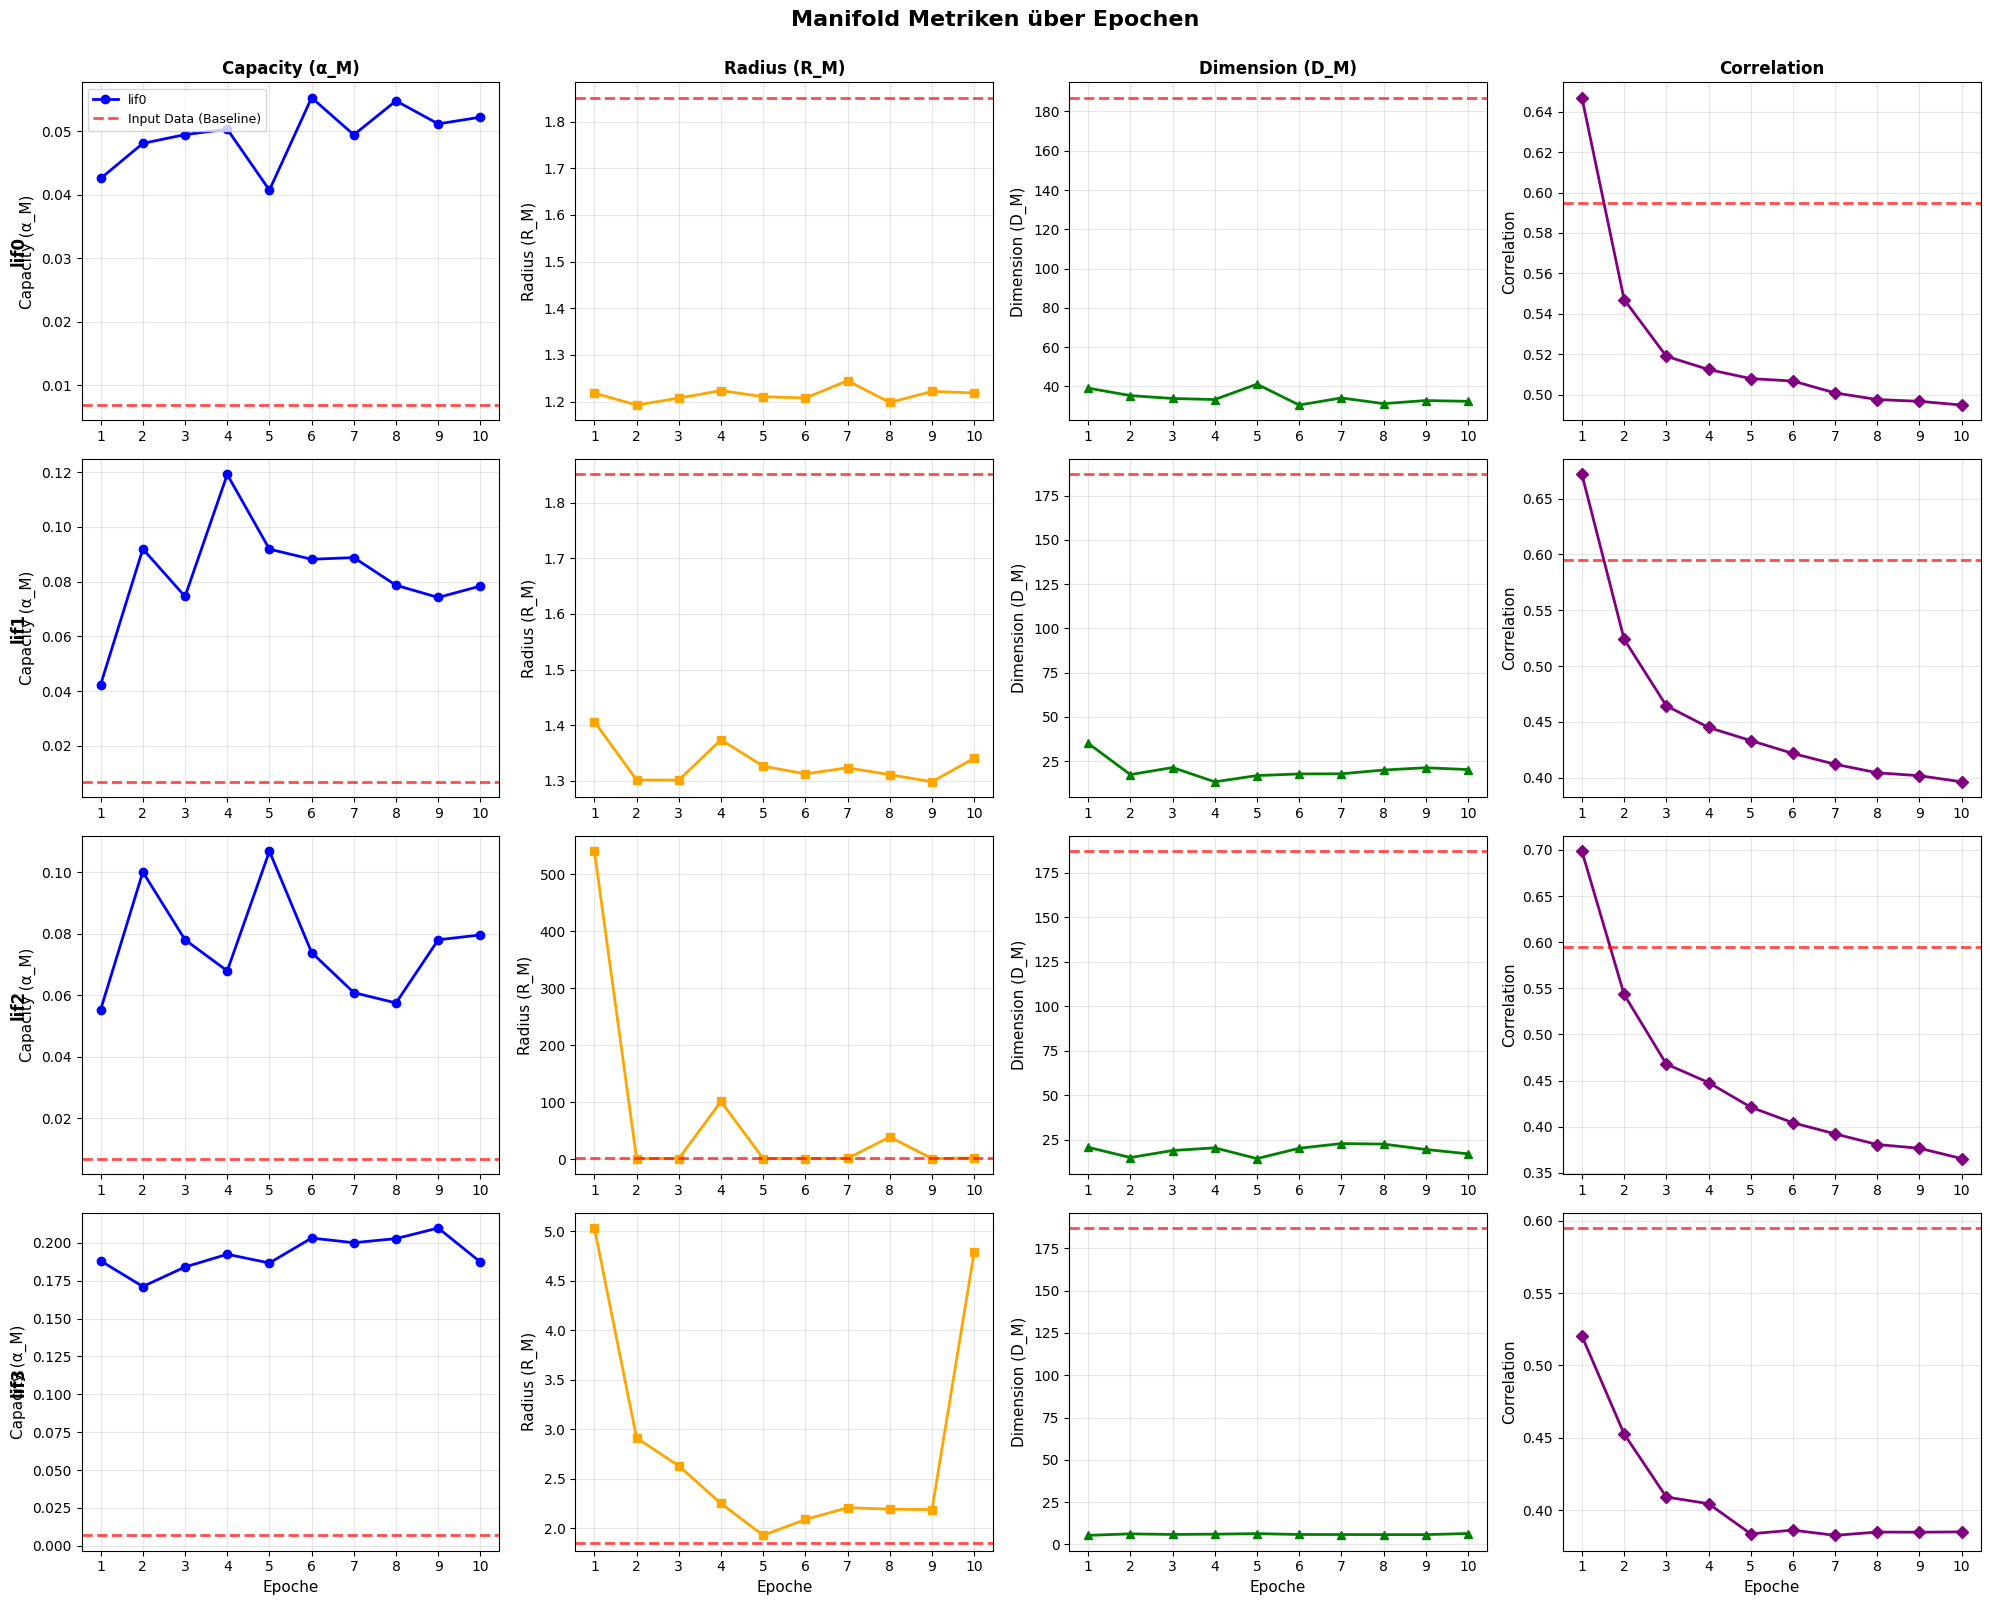

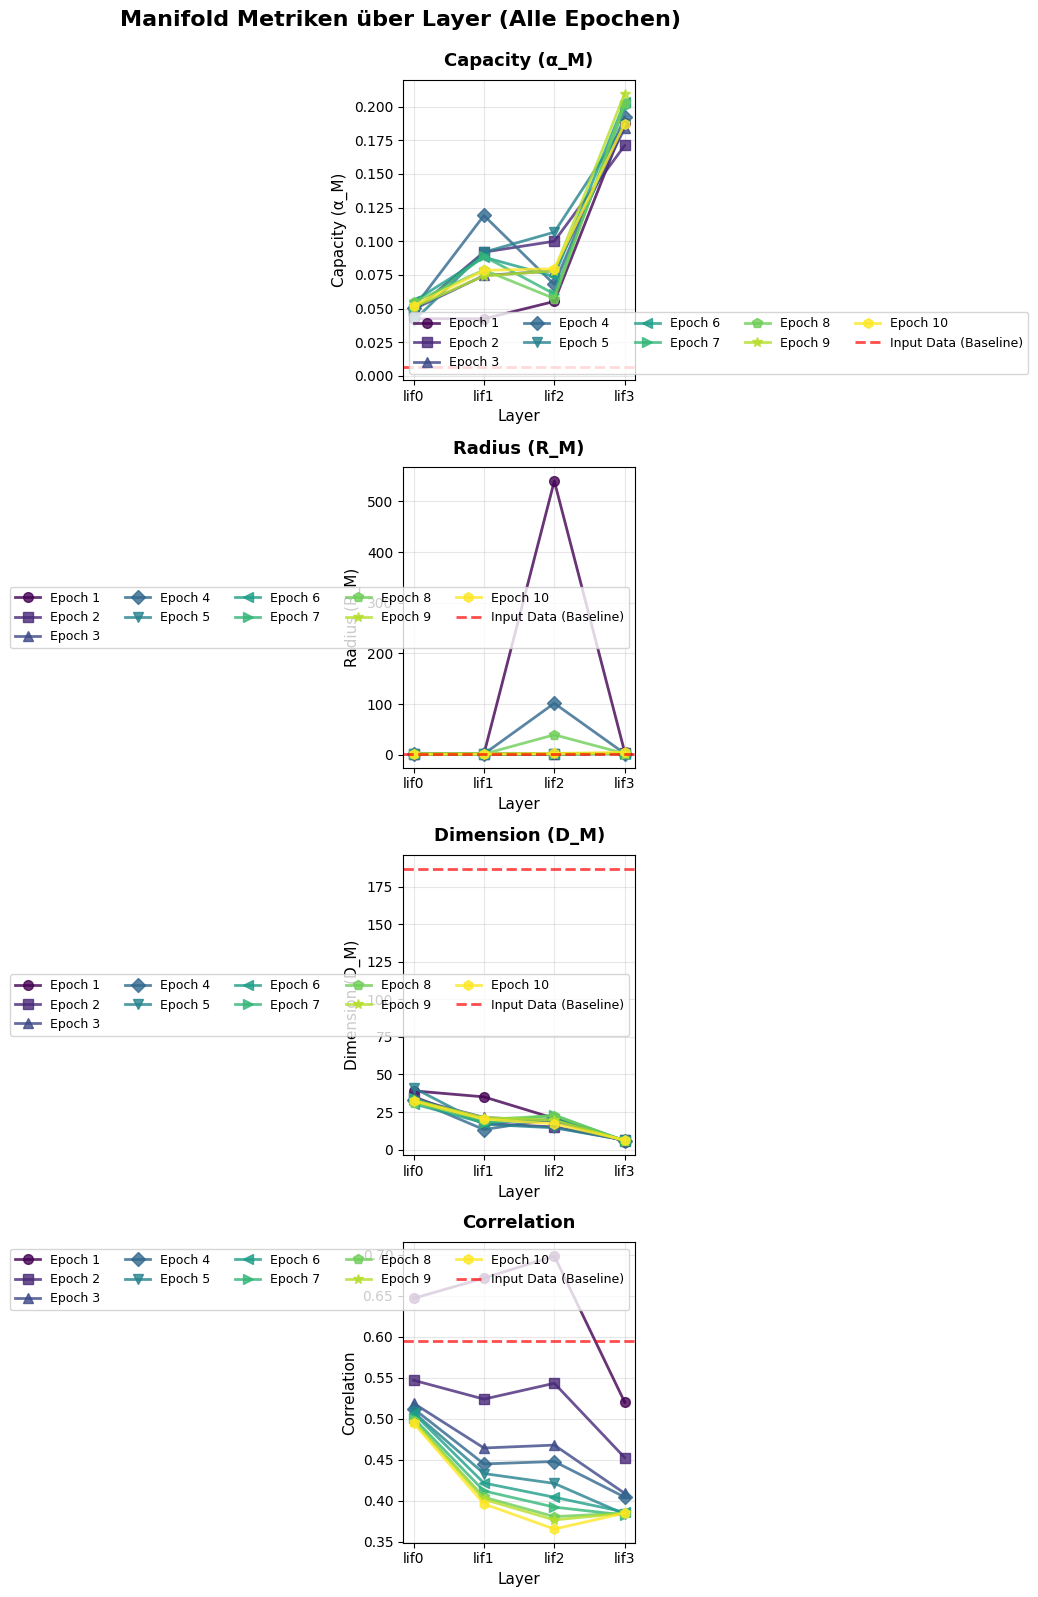

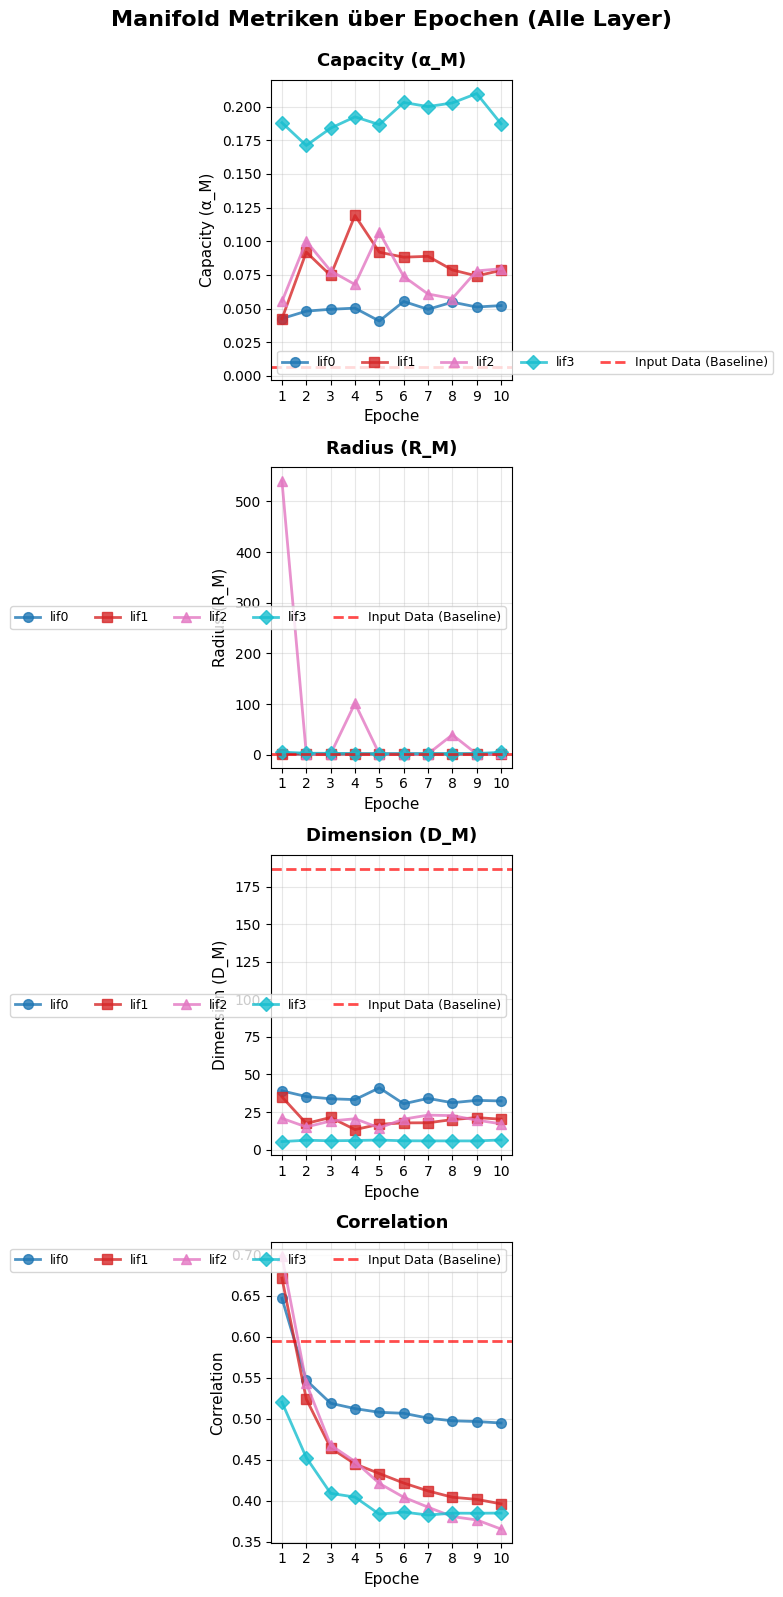

In [ ]:
plot_manifold_metrics_over_epochs(
    results_json_path=results_json_path, 
    input_data_metrics=results_input, 
    save_dir=plots_dir, 
    figsize_per_subplot=(5, 4)
)

plot_manifold_metrics_over_layer(
    results_json_path=results_json_path, 
    input_data_metrics=results_input, 
    save_dir=plots_dir, 
    figsize_per_subplot=(5, 4)
)

plot_manifold_metrics_over_epochs_all_layer_in_one_plot(
    results_json_path=results_json_path, 
    input_data_metrics=results_input, 
    save_dir=plots_dir, 
    figsize_per_subplot=(5, 4)
)

print(f"✅ All global performance and manifold plots saved in {plots_dir}")